In [6]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [7]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

from utils.solver import Solver
from utils.vapour_reactor_utils import plot_reactor_solutions
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor

In [8]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 600

MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [9]:
Ns = [15, 65, 40]
cfg = generate_config(data, *Ns)
cfg_interp = generate_config(data, *Ns)

reactor = VapourReactor(cfg)

reactor_interp = VapourReactor(cfg_interp)
reactor_interp.set_interpolator_model(interpolator_model)

solver = Solver([reactor, reactor_interp], iterate=True)
solver.fsolve()

Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...


/home/karlandersson/Programming/MasterThesisProject/models/neutronics/axial_neutron_model.py:139: RuntimeWarning: overflow encountered in multiply
  (D_n_g[mask_nm1] * D_nm1_g[mask_nm1]) /
/home/karlandersson/Programming/MasterThesisProject/models/neutronics/axial_neutron_model.py:145: RuntimeWarning: overflow encountered in multiply
  (D_n_g[mask_np1] * D_np1_g[mask_np1]) /
/home/karlandersson/Programming/MasterThesisProject/models/neutronics/axial_neutron_model.py:96: RuntimeWarning: invalid value encountered in add
  a_n_g * phi_n_g + b_n_g * phi_np1_g + c_n_g * phi_nm1_g + Sigma_t * phi_n_g


ValueError: One of the requested xi is out of bounds in dimension 0

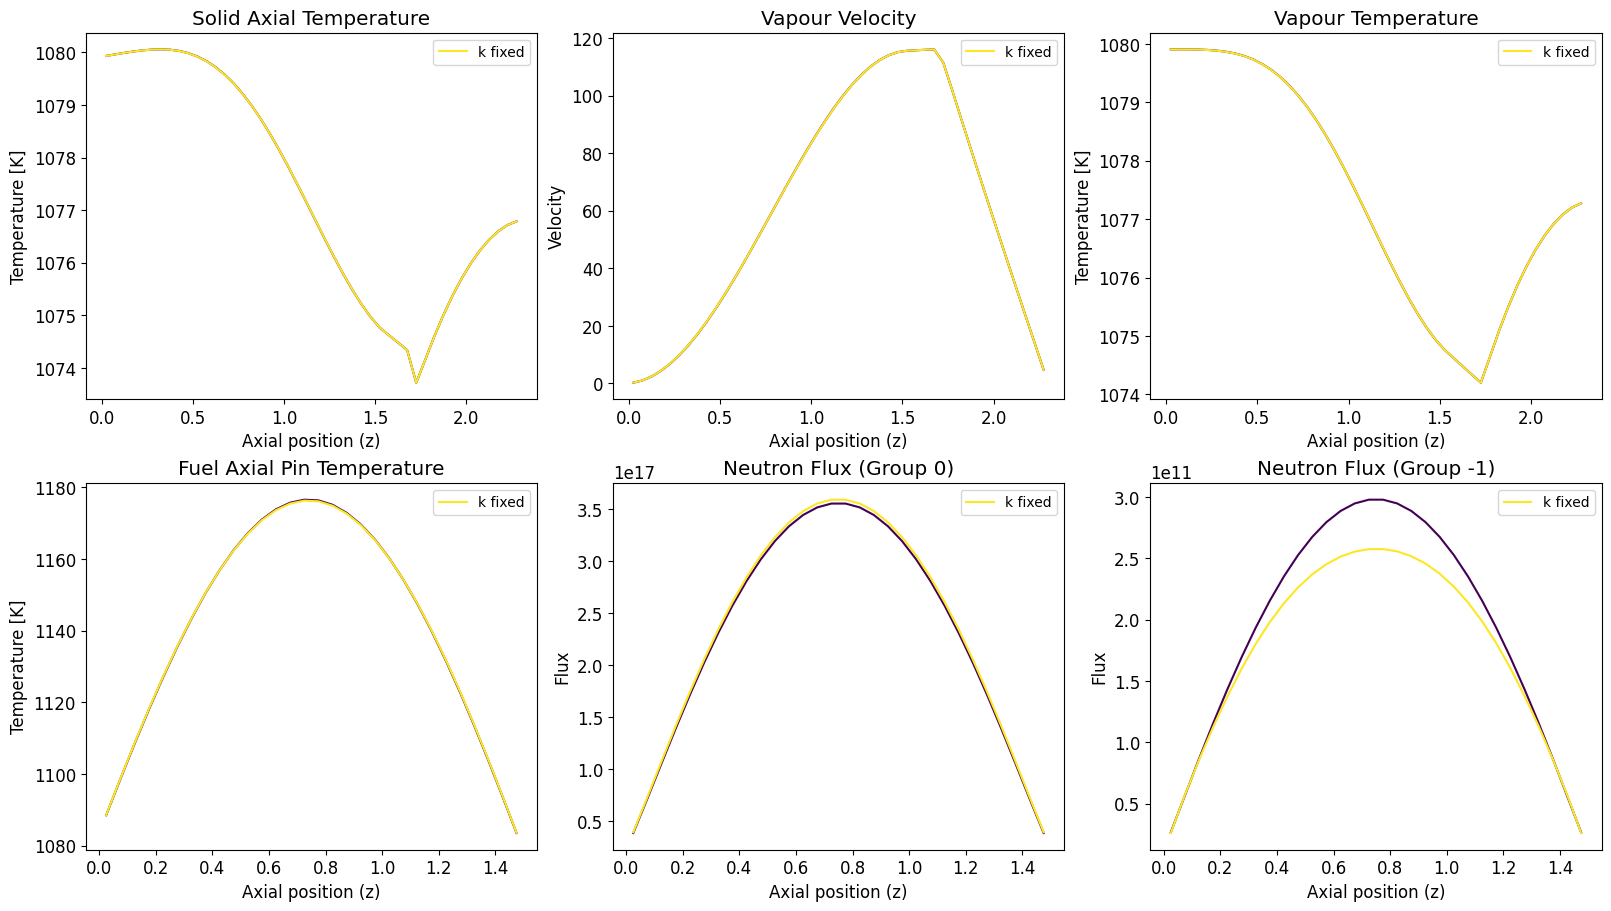

In [ ]:
plot_reactor_solutions(solver)